# Notebook III - Climatic Constraints

<hr>
This module uses various yield reduction factors to apply the obtained maximum attainable yield from Module 2 to consider the constraint effects separately from Module II. This modules works with two separate python look-up scripts ALL_REDUCTION_FACTORS_IRR and ALL_REDUCTION_FACTORS_RAIN which must be manually edited for crop/LUT specific reduction factors.

Prepared by Geoinformatics Center, AIT
<hr>

### Google drive connection
In this step, we will connect to Google Drive service and mount the drive where we will start our PyAEZ project

In [1]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

Then, installing any additional python packages that required to run PyAEZ.
If working on your own PC/machine, these additional installation will vary depending on what is already installed in your Python library. 

In [2]:
# 'Installing neccessary packages'
# !pip install gdal

## Importing Libraries

In [3]:
'''import supporting libraries'''
# import pyaez
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import xarray as xr

try:
    from osgeo import gdal
except:
    import gdal
import sys

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
gdal.UseExceptions() 


In [4]:
from pyaez_main import initialize_climatic_constraints

work_dir = r'/workspaces/Python-AEZ-FAO'  # Please change this to your working directory
country_name = 'togo'
country_mask_name = 'togo_rasterized.tif'
elevation_filename = 'togo_elevation_resampled_clipped.tif'
year = '1980'

clim_con = initialize_climatic_constraints(work_dir, country_name, country_mask_name, elevation_filename, year)

Available crops:
1. maize
2. rice
3. soybean
4. sugarcane
5. cassava
6. cocoa
7. coffee
8. cashew


Select a crop by number:  5


You selected: cassava


In [5]:
from pyaez_main import compute_yield

condition_type = 'rainfed'
clim_yield_rain, fc3_rain = compute_yield(clim_con, condition_type, work_dir, country_name, year)


FileNotFoundError: [Errno 2] No such file or directory: './data_input/input_module3/Cassava_High_rf_lst.xlsx'

Setting the working directory -- where our PyAEZ project is located.

In [4]:
'Set the working directory'
os.chdir(work_dir)
sys.path.append(work_dir)
os.getcwd()


'/workspaces/Python-AEZ-FAO'

Check and create data output folder

In [5]:
import os
folder_path = './data_output/NB3/'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print("Folder created successfully.")
else:
    print("Folder already exists.")


Folder already exists.


Preparing required inputs for object class

In [6]:
mask_path=r'./data_input/togo_rasterized.tif'
mask_gdal = gdal.Open(mask_path)
mask = mask_gdal.ReadAsArray()
elevation = gdal.Open(r'./data_input/togo_elevation_resampled_clipped.tif').ReadAsArray()

In [7]:
import pandas as pd

YEAR = '1980'
CAVA_data = True
df = pd.read_excel(r'./data_input/input_crop_TSUM_parameters_TOGO_HI.xlsx')
df


,Crop_name,SDG,input_level,HI,LAI,legume,adaptability,cycle_len,min_cycle_len,max_cycle_len,...,aLAI,bLAI,aHI,bHI,LnS,LsO,LO,HnS,HsO,HO
0,maize,6.0,high,0.45,4.0,0.0,3.0,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2422.50,2550,2750.0,4725.0,5400.0,5670.00
1,rice,6.0,high,0.50,6.5,0.0,2.0,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2636.25,2775,2887.5,3750.0,4050.0,4252.50
2,soybean,5.0,high,0.36,4.5,1.0,2.0,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2565.00,2700,2850.0,3850.0,4200.0,4410.00
3,sugarcane,8.0,high,0.25,7.0,0.0,3.0,330.0,150.0,360.0,...,70.0,200.0,120.0,180.0,5700.00,6000,6750.0,10000.0,10950.0,11497.50
4,cassava,3.0,high,0.50,3.0,0.0,2.0,270.0,216.0,297.0,...,0.0,240.0,60.0,120.0,6175.00,6500,7500.0,10950.0,12775.0,13413.75
5,cocoa,1.0,high,0.09,3.9,0.0,1.0,300.0,240.0,330.0,...,0.0,270.0,120.0,150.0,7362.50,7750,8500.0,9750.0,10950.0,11497.50
6,coffee,3.0,high,0.13,3.0,0.0,2.0,270.0,216.0,297.0,...,0.0,270.0,90.0,180.0,6887.50,7250,8000.0,10950.0,12775.0,13413.75
7,cashew,3.0,high,0.15,3.5,0.0,2.0,180.0,144.0,198.0,...,0.0,270.0,90.0,180.0,8312.50,8750,7000.0,10950.0,12775.0,13413.75
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
crop_name = df.Crop_name[4]

In [9]:
# Extract the geotransform
geotransform = mask_gdal.GetGeoTransform()

# Get the bounds from the geotransform
minx = geotransform[0]  # Top-left corner X (longitude)
miny = geotransform[3] + geotransform[5] * mask_gdal.RasterYSize  # Bottom-left corner Y (latitude)
maxx = geotransform[0] + geotransform[1] * mask_gdal.RasterXSize  # Top-right corner X (longitude)
maxy = geotransform[3]  # Top-left corner Y (latitude)

# Print the bounding box (min longitude, min latitude, max longitude, max latitude)
print(f"Longitude bounds: ({minx}, {maxx})")
print(f"Latitude bounds: ({miny}, {maxy})")

Longitude bounds: (-1.0, 2.75)
Latitude bounds: (5.2499998807907104, 12.0)


In [10]:
# Define the Area-Of-Interest's geographical extents
lat_min = miny
lat_max = maxy
mask_value = 0  # pixel value in admin_mask to exclude from the analysis
daily = True #Type of climate data = True: daily, False: monthly

In [11]:
# Load climate data
data_input = os.path.join(work_dir, 'data_input', 'CAVA_data')
max_temp = np.load(os.path.join(data_input, 'tasmax.npy'))
min_temp = np.load(os.path.join(data_input, 'tasmin.npy'))
precipitation = np.load(os.path.join(data_input, 'pr.npy'))
rel_humidity = np.load(os.path.join(data_input, 'hurs.npy'))
wind_speed = np.load(os.path.join(data_input, 'sfcWind.npy'))
short_rad = np.load(os.path.join(data_input, 'rsds.npy'))
times = np.load(os.path.join(data_input, 'time_array.npy'))

# Agro-climatic Indicators
lgp = gdal.Open(rf'./data_output/NB1/{country_name}_LGP_{YEAR}.tif').ReadAsArray()
lgp10 = gdal.Open(rf'./data_output/NB1/{country_name}_LGPt10_{YEAR}.tif').ReadAsArray()
lgp_equv = gdal.Open(rf'./data_output/NB1/{country_name}_LGPEquivalent_{YEAR}.tif').ReadAsArray()

# Yield Map
yield_map_rain = gdal.Open(rf'./data_output/NB2/{country_name}_{crop_name}_yld_rain_{YEAR}.tif').ReadAsArray()
yield_map_irr = gdal.Open(rf'./data_output/NB2/{country_name}_{crop_name}_yld_irr_{YEAR}.tif').ReadAsArray()

red_times_idx = [i for i,t in enumerate(times) if YEAR in str(t)]


## Applying Climate Constraints

In [12]:
'''importing library'''

from pyaez import ClimaticConstraints
clim_con = ClimaticConstraints.ClimaticConstraints(lat_min = lat_min, lat_max =lat_max, 
                                                   elevation=elevation, mask = mask , 
                                                   no_mask_value=0)

from pyaez.UtilitiesCalc import saveRaster

Importing climate data into the object class

In [13]:
clim_con.setClimateData(min_temp= min_temp[:,:,red_times_idx], 
                        max_temp= max_temp[:,:,red_times_idx], 
                        wind_speed= wind_speed[:,:,red_times_idx],
                        short_rad= short_rad[:,:,red_times_idx], 
                        rel_humidity= rel_humidity[:,:,red_times_idx], 
                        precip= precipitation[:,:,red_times_idx])

Agro-climatic Reduction Factors are now set up for a single water supply condition with
the excel sheet

In [60]:
df

,Crop_name,SDG,input_level,HI,LAI,legume,adaptability,cycle_len,min_cycle_len,max_cycle_len,...,aLAI,bLAI,aHI,bHI,LnS,LsO,LO,HnS,HsO,HO
0,maize,6.0,high,0.45,4.0,0.0,3,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2422.50,2550.0,2750.0,4725.0,5400.0,5670.00
1,rice,6.0,high,0.50,6.5,0.0,2,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2636.25,2775.0,2887.5,3750.0,4050.0,4252.50
2,soybean,5.0,high,0.36,4.5,1.0,2,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2565.00,2700.0,2850.0,3850.0,4200.0,4410.00
3,sugarcane,8.0,high,0.25,7.0,0.0,3,330.0,150.0,360.0,...,70.0,200.0,120.0,180.0,5700.00,6000.0,6750.0,10000.0,10950.0,11497.50
4,cassava,3.0,high,0.50,3.0,0.0,2,270.0,216.0,297.0,...,0.0,240.0,60.0,120.0,6175.00,6500.0,7500.0,10950.0,12775.0,13413.75
5,cocoa,1.0,high,0.09,3.9,0.0,1,300.0,240.0,330.0,...,0.0,270.0,120.0,150.0,7362.50,7750.0,8500.0,9750.0,10950.0,11497.50
6,coffee,3.0,high,0.13,3.0,0.0,2,270.0,216.0,297.0,...,0.0,270.0,90.0,180.0,6887.50,7250.0,8000.0,10950.0,12775.0,13413.75
7,cashew,NaN,high,NaN,NaN,NaN,2,NaN,NaN,NaN,...,0.0,270.0,90.0,180.0,0.00,NaN,NaN,NaN,NaN,0.00


In [61]:
crop_name

'coffee'

In [4]:
# In this notebook, we will explore for rainfed conditons' agro-climatic constraints
# Indica wetland rice_High_ir_lst.xlsx
# Indica wetland rice_High_rf_lst.xlsx
# Maize (tropical lowland  cultivars)_High_ir_lst.xlsx
# Maize (tropical lowland  cultivars)_High_rf_lst.xlsx
# Soybean (tropical and subtropical cultivars)_High_ir_lst.xlsx
# Soybean (tropical and subtropical cultivars)_High_rf_lst.xlsx

if crop_name in ['maize_H','maize']:
    filename_ir = r'./data_input/Maize (tropical lowland  cultivars)_High_ir_lst.xlsx'
    filename_rf = r'./data_input/Maize (tropical lowland  cultivars)_High_rf_lst.xlsx'
elif crop_name in ['rice_H','rice']:
    filename_ir = r'./data_input/Indica wetland rice_High_ir_lst.xlsx'
    filename_rf = r'./data_input/Indica wetland rice_High_rf_lst.xlsx'
elif crop_name in ['soybean_H','soybean']:
    filename_ir = r'./data_input/Soybean (tropical and subtropical cultivars)_High_ir_lst.xlsx'
    filename_rf = r'./data_input/Soybean (tropical and subtropical cultivars)_High_rf_lst.xlsx'
elif crop_name in ['cassava_H','cassava']:
    filename_ir = r'./data_input/Cassava_High_ir_lst.xlsx'
    filename_rf = r'./data_input/Cassava_High_rf_lst.xlsx'
elif crop_name in ['cocoa_H','cocoa']:
    filename_ir = r'./data_input/Cocoa_High_ir_lst.xlsx'
    filename_rf = r'./data_input/Cocoa_High_rf_lst.xlsx'
elif crop_name in ['coffee_H','coffee']:
    filename_ir = r'./data_input/Coffee_robusta_High_ir_lst.xlsx'
    filename_rf = r'./data_input/Coffee_robusta_High_rf_lst.xlsx'

NameError: name 'crop_name' is not defined

# Rainfed condition

In [63]:
filename_rf

'./data_input/Coffee_robusta_High_rf_lst.xlsx'

In [65]:
'''Applying climatic constraints. Note that constraints for rainfed and irrigated conditions are run separately'''
# Yield Reduction for Rainfed Conditions

clim_con.setReductionFactors(file_path= filename_rf)

clim_con.applyClimaticConstraints(yield_input=yield_map_rain, lgp=lgp, lgp_equv=lgp_equv, 
                                  lgpt10=lgp10, omit_yld_0 = True)


# Getting the climate adjusted yield (rainfed)
clim_yield_rain = clim_con.getClimateAdjustedYield()

# Getting agro-climatic constraint factor (fc3) (rainfed)
fc3_rain = clim_con.getClimateReductionFactor()

Text(0.5, 1.0, 'Fc3 coffee Rainfed')

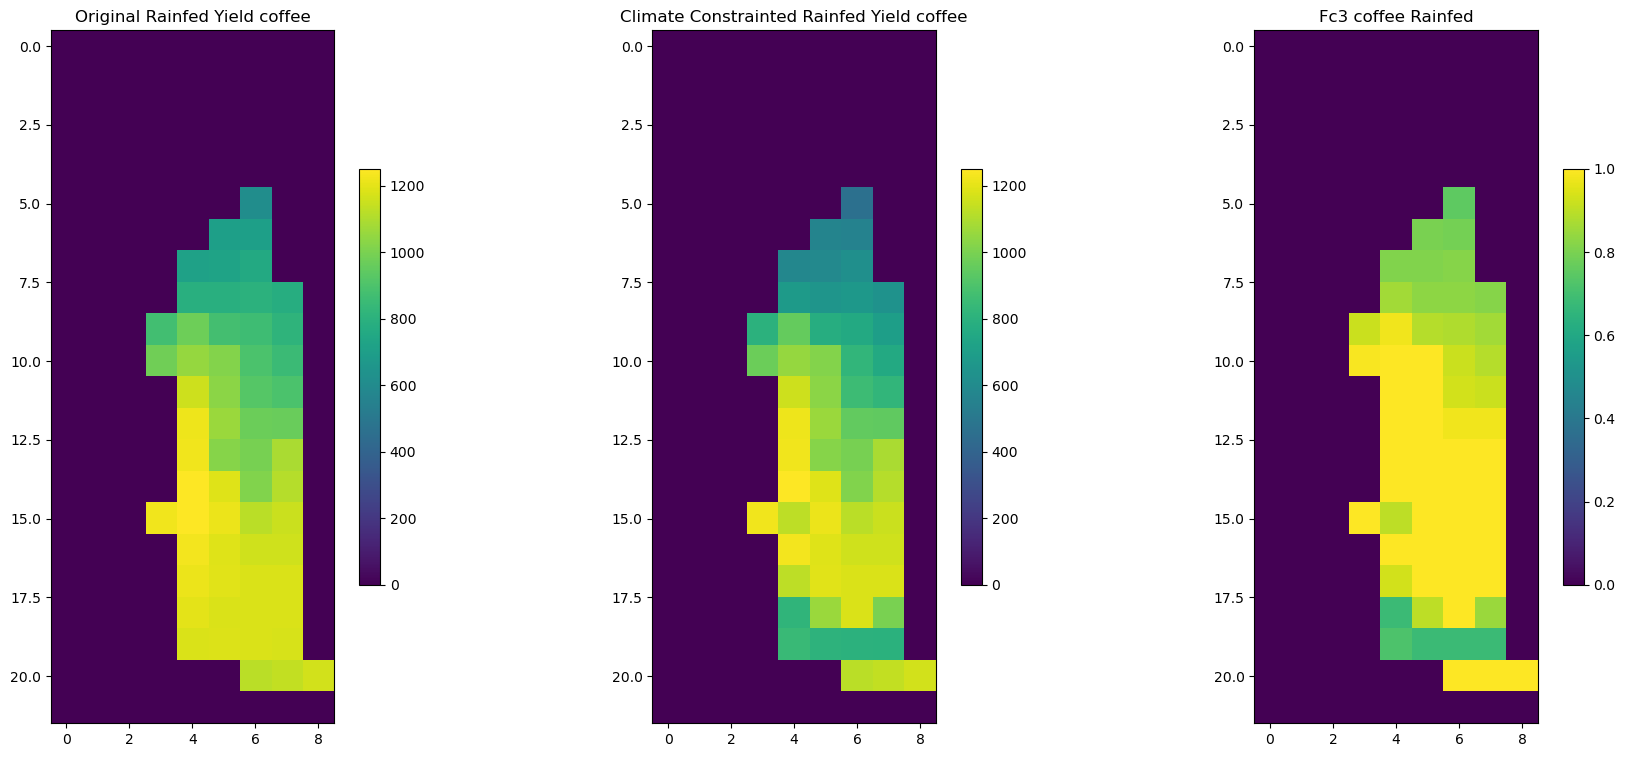

In [66]:
'''visualize results'''
plt.figure(1, figsize=(22,9))
plt.subplot(1,3,1)
plt.imshow(yield_map_rain, vmax = np.max([clim_yield_rain, yield_map_rain]))
plt.colorbar(shrink=0.6)
plt.title(f'Original Rainfed Yield {crop_name}')

plt.subplot(1,3,2)
plt.imshow(clim_yield_rain, vmax = np.max([clim_yield_rain, yield_map_rain]))
plt.colorbar(shrink=0.6)
plt.title(f'Climate Constrainted Rainfed Yield {crop_name}')

plt.subplot(1,3,3)
plt.imshow(fc3_rain, vmax = 1)
plt.colorbar(shrink=0.6)
plt.title(f'Fc3 {crop_name} Rainfed')


In [67]:
'''save result (Rainfed Condition)'''
saveRaster(mask_path, rf'./data_output/NB3/{crop_name}_yld_rain_m3.tif', clim_yield_rain)
saveRaster(mask_path, rf'./data_output/NB3/fc3_{crop_name}_rain.tif', fc3_rain)

# Irrigated condition

Let's run same this for irrigated condition

In [68]:
clim_con.setReductionFactors(file_path= filename_ir)

In [69]:
'''Applying climatic constraints. Note that constraints for rainfed and irrigated conditions are run separately'''
# Yield Reduction for Rainfed Conditions
clim_con.applyClimaticConstraints(yield_input=yield_map_irr, lgp=lgp, lgp_equv=lgp_equv, 
                                  lgpt10=lgp10, omit_yld_0 = True)


# Getting the climate adjusted yield (rainfed)
clim_yield_irr = clim_con.getClimateAdjustedYield()

# Getting agro-climatic constraint factor (fc3) (rainfed)
fc3_irr = clim_con.getClimateReductionFactor()

Text(0.5, 1.0, 'Fc3 coffee Irrigated')

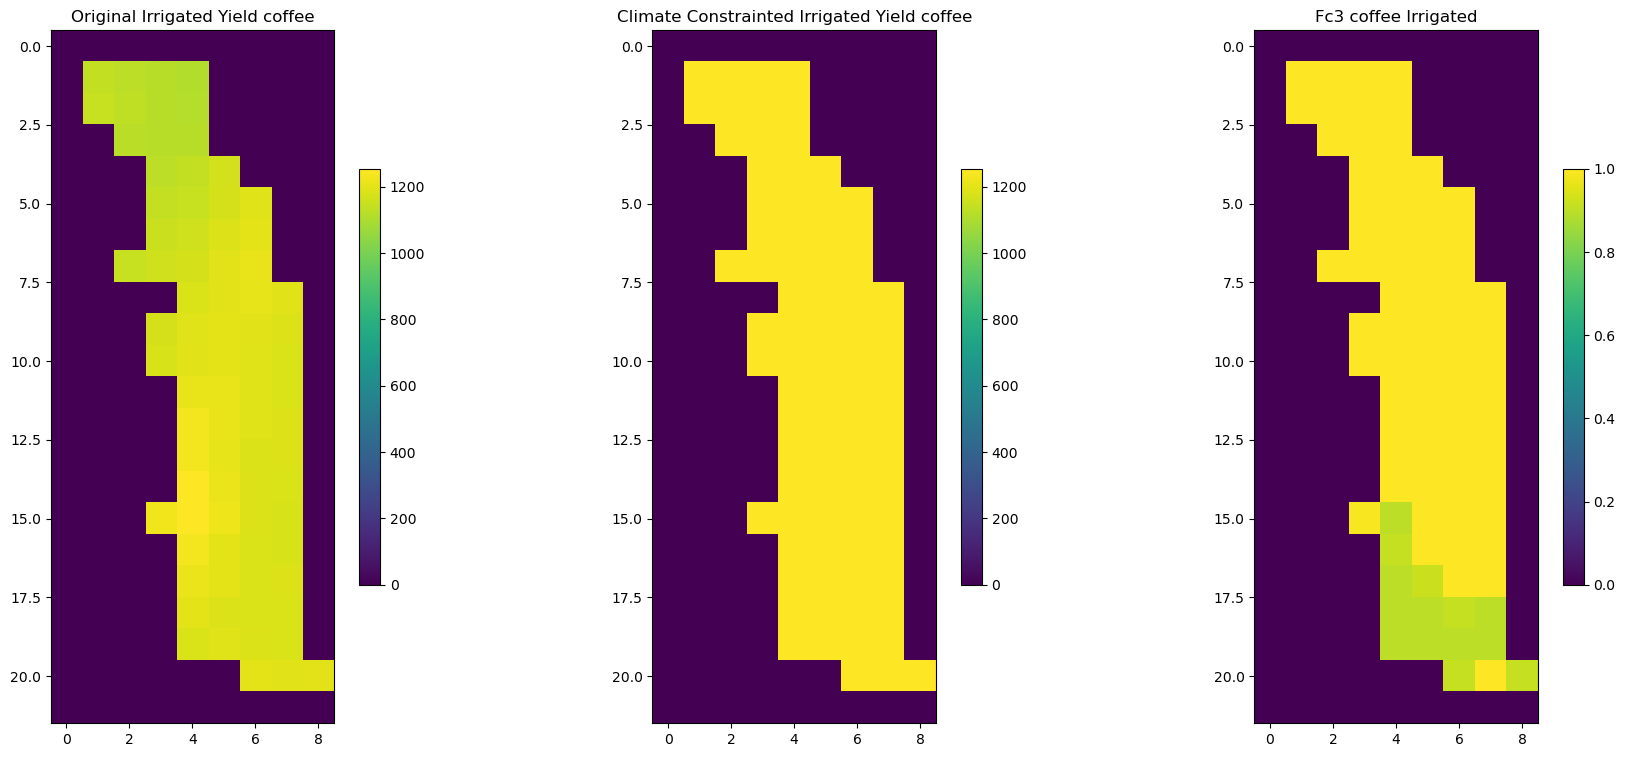

In [70]:
'''visualize results'''
plt.figure(1, figsize=(22,9))
plt.subplot(1,3,1)
plt.imshow(yield_map_irr, vmax = np.max([clim_yield_irr, yield_map_irr]))
plt.colorbar(shrink=0.6)
plt.title(f'Original Irrigated Yield {crop_name}')

plt.subplot(1,3,2)
plt.imshow(clim_yield_irr_maiz, vmax = np.max([clim_yield_irr, yield_map_irr]))
plt.colorbar(shrink=0.6)
plt.title(f'Climate Constrainted Irrigated Yield {crop_name}')

plt.subplot(1,3,3)
plt.imshow(fc3_maiz_irr, vmax = 1)
plt.colorbar(shrink=0.6)
plt.title(f'Fc3 {crop_name} Irrigated')


In [71]:
'''save result (Irrigated Condition)'''
saveRaster(mask_path, rf'./data_output/NB3/{crop_name}_yld_irr_m3.tif', clim_yield_irr)
saveRaster(mask_path, rf'./data_output/NB3/fc3_{crop_name}_irr.tif', fc3_irr)
saveRaster(mask_path, r'./data_output/NB3/lgpagc.tif', clim_con.lgp_agc)

<hr>

### END OF MODULE 3: CLIMATIC CONSTRAINTS

<hr>